# ANALYSIS OF SPLITTING

In [1]:
from src.score import Score
from src.linear_predictor import LinearPredictor
import os
import src.constants as cn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.biomodels_iterator import BiomodelsIterator
from src.trajectory import Trajectory
from src.trajectory_collection import TrajectoryCollection
from src.multiple_linear_predictor import MultipleLinearPredictor

# Helpers

In [2]:
def evaluateMlp(model_num, num_splits=2, is_slow_subspace: bool = False, is_species_prediction: bool = False, **kwargs):
    if not isinstance(num_splits, list):
        num_splits = [num_splits]
    trajectory = Trajectory.makeBiomodel(model_num=model_num, end_time=10)
    tcs = [TrajectoryCollection.autoSplit(trajectory, num_split=n, is_slow_subspace=is_slow_subspace,
            is_species_prediction=is_species_prediction) for n in num_splits]
    #
    lp = LinearPredictor(trajectory, is_species_prediction=is_species_prediction)
    lp.plotPrediction(**kwargs)
    #
    for tc in tcs:
        mlp = MultipleLinearPredictor(tc, is_slow_subspace=is_slow_subspace, is_species_prediction=is_species_prediction)
        mlp.plotPrediction(**kwargs)

# Timeseries Plots

# Splitting

## slow=False, species=False

Cannot use JAC_FITTED: num_species (5) > num_point (2).
Error occurred while processing segment 1: zero-size array to reduction operation fmin which has no identity
Cannot use JAC_FITTED: num_species (5) > num_point (2).
Cannot use JAC_FITTED: num_species (5) > num_point (2).
Error occurred while processing segment 1: zero-size array to reduction operation fmin which has no identity
Error occurred while processing segment 2: zero-size array to reduction operation fmin which has no identity


/Users/jlheller/home/Technical/repos/model_linearity_analysis/src/score.py:253: RuntimeWarning:

Mean of empty slice

/Users/jlheller/home/Technical/repos/model_linearity_analysis/src/score.py:253: RuntimeWarning:

Mean of empty slice



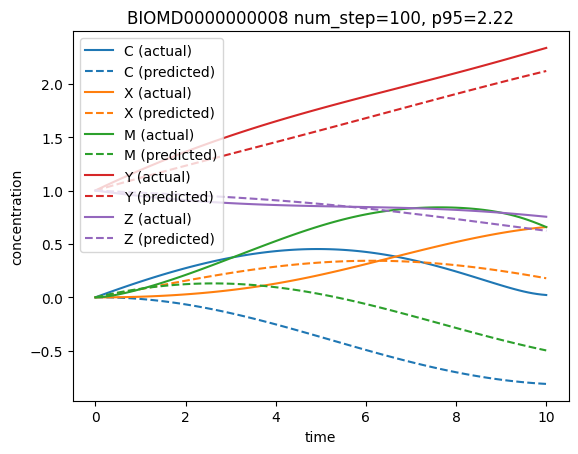

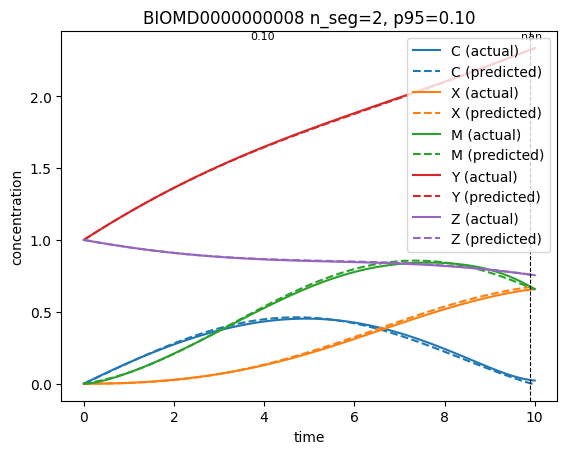

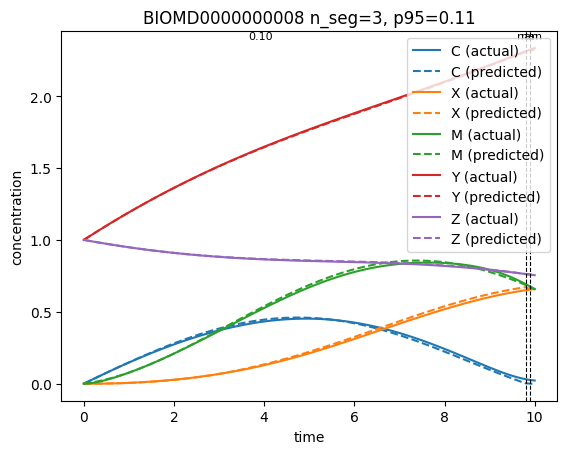

In [3]:
evaluateMlp(8, num_splits=[1, 2])

## slow=True, species=False

Cannot use JAC_FITTED: num_species (5) > num_point (2).
Error occurred while processing segment 1: zero-size array to reduction operation fmin which has no identity


/Users/jlheller/home/Technical/repos/model_linearity_analysis/src/score.py:253: RuntimeWarning:

Mean of empty slice



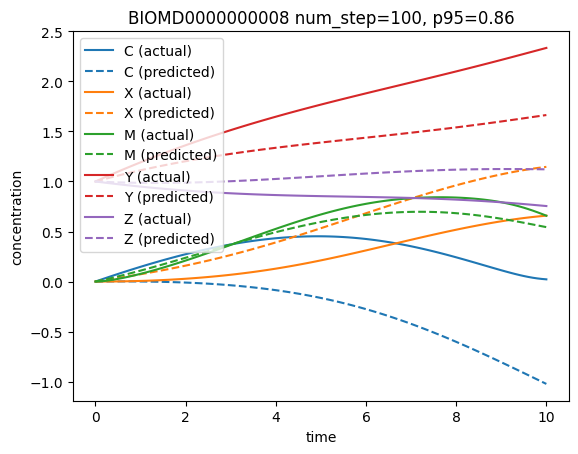

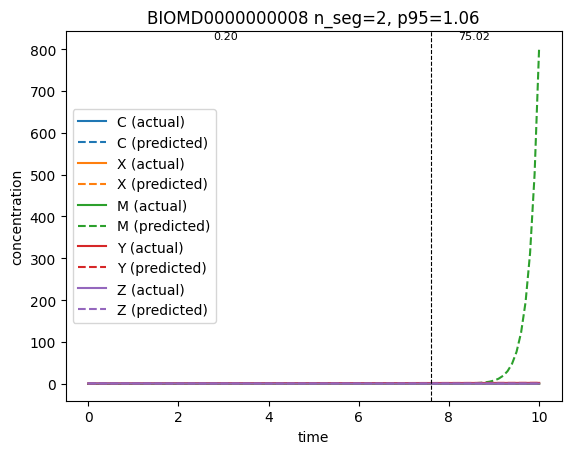

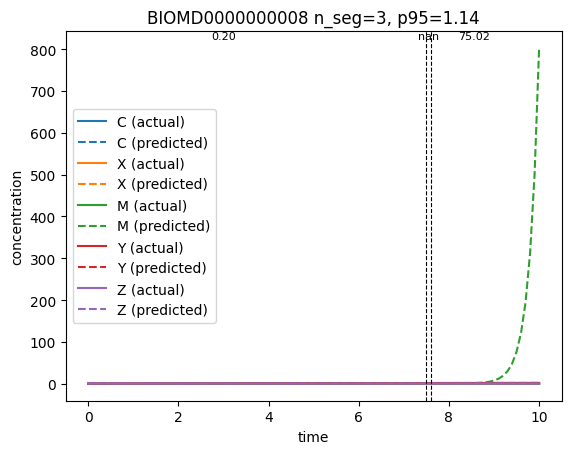

In [4]:
evaluateMlp(8, num_splits=[1, 2], is_species_prediction=True)

## slow=False, speices=True

Cannot use JAC_FITTED: num_species (5) > num_point (2).
Error occurred while processing segment 1: zero-size array to reduction operation fmin which has no identity


/Users/jlheller/home/Technical/repos/model_linearity_analysis/src/score.py:253: RuntimeWarning:

Mean of empty slice



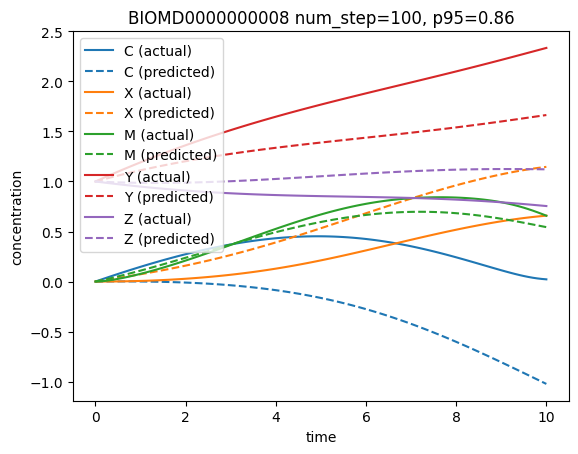

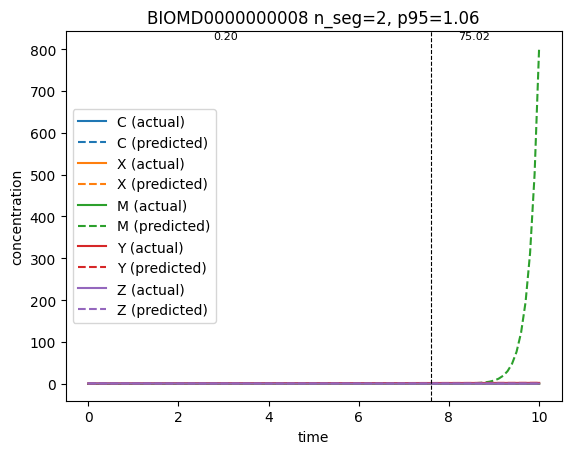

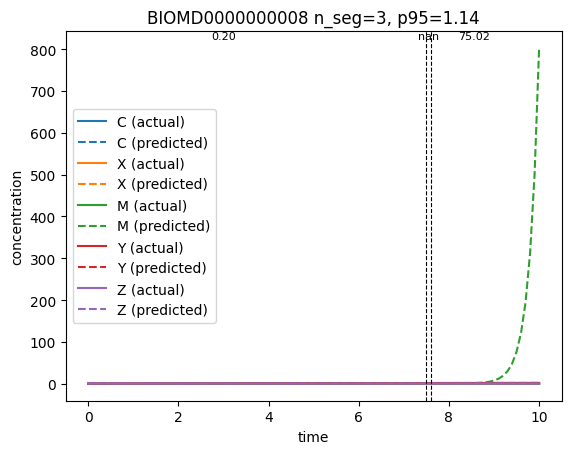

In [5]:
evaluateMlp(8, num_splits=[1, 2], is_species_prediction=True)

## slow=True, species=True

Error occurred while processing segment 1: zero-size array to reduction operation fmin which has no identity
Error occurred while processing segment 1: zero-size array to reduction operation fmin which has no identity
Error occurred while processing segment 2: zero-size array to reduction operation fmin which has no identity


/Users/jlheller/home/Technical/repos/model_linearity_analysis/src/score.py:253: RuntimeWarning:

Mean of empty slice

/Users/jlheller/home/Technical/repos/model_linearity_analysis/src/score.py:253: RuntimeWarning:

Mean of empty slice



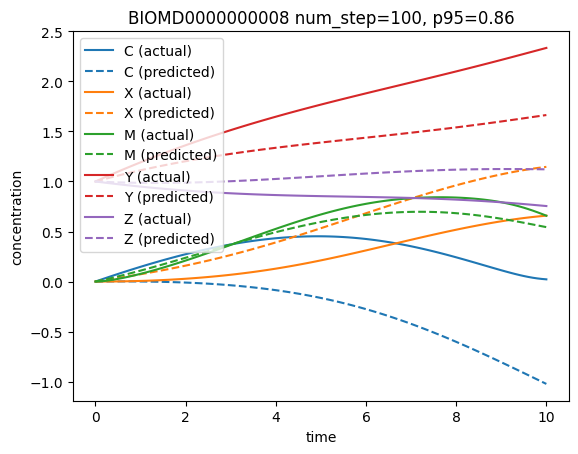

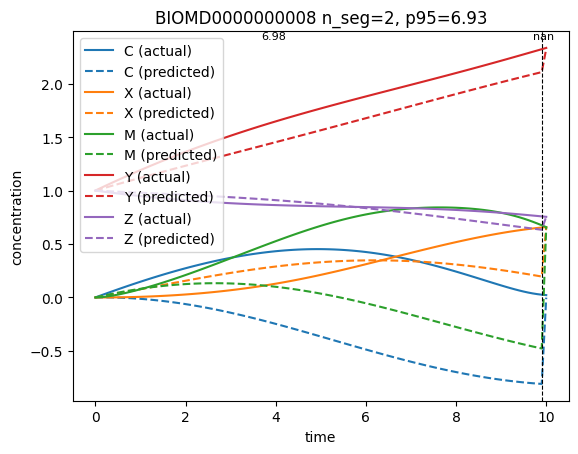

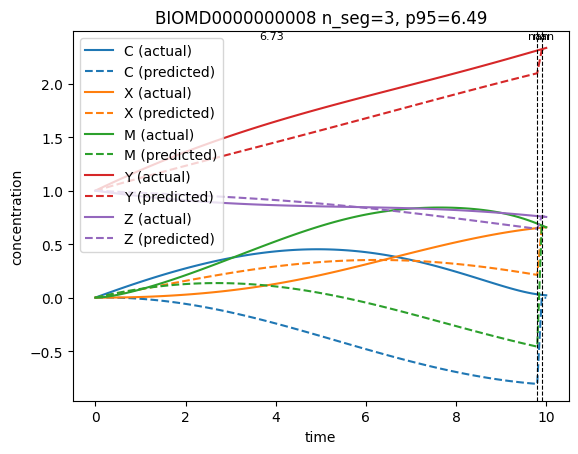

In [6]:
evaluateMlp(8, num_splits=[1, 2], is_slow_subspace=True, is_species_prediction=True)

## Iterate across many

In [7]:
STOP

NameError: name 'STOP' is not defined

In [ ]:
iterator = BiomodelsIterator(
            is_report=False,
            #excluded_models=excluded_models,
            first_model_num=1,
            last_model_num=200)
for item in iterator:
    if item.model_num in [11, 13, 14, 19, 38, 41, 48, 50]:
        print(f"Excluding model {item.model_num}")
        continue
    try:
        print(f"Processing {item.model_num}")
        evaluateMlp(item.model_num, num_splits=[1, 2], is_slow_subspace=True)
    except:
        print(f"Failed on model {item.model_num}")
    

In [ ]:
#evaluateMlp(599, num_split=1, legend=False)

In [ ]:
evaluateMlp(115, num_splits=[1, 2], ylim=[0, 10], legend=True)

In [ ]:
evaluateMlp(40, num_splits=[1,5],legend=False)

In [ ]:
iterator = BiomodelsIterator(
            is_report=False,
            #excluded_models=excluded_models,
            first_model_num=1,
            last_model_num=200)
for item in iterator:
    if item.model_num in [11, 13, 14, 19, 38, 41, 48, 50]:
        print(f"Excluding model {item.model_num}")
        continue
    try:
        print(f"Processing {item.model_num}")
        evaluateMlp(item.model_num, num_splits=[1, 2], is_slow_subspace=True)
    except:
        print(f"Failed on model {item.model_num}")
    

# Manual Analysis

Error fitting Jacobian: NaN values detected in your input data or the output of your objective/model function - fitting algorithms cannot handle this! Please read https://lmfit.github.io/lmfit-py/faq.html#i-get-errors-from-nan-in-my-fit-what-can-i-do for more information.
Falling back to JAC_MEDIAN.


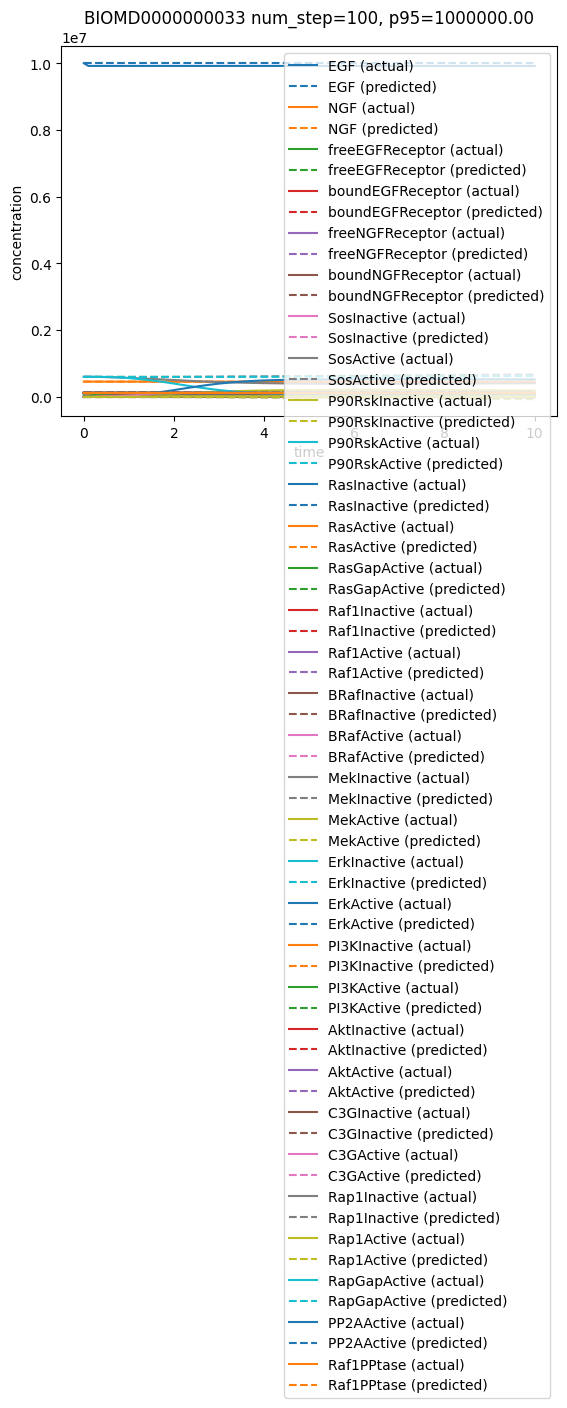

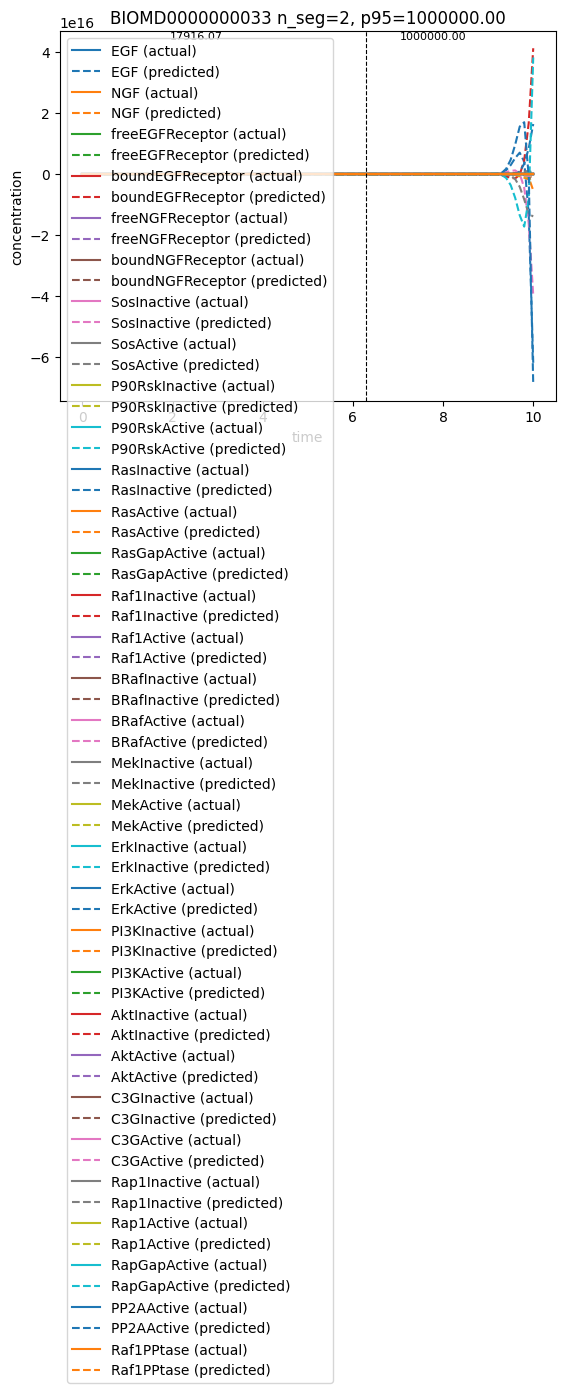

In [8]:
evaluateMlp(33, num_splits=[1])

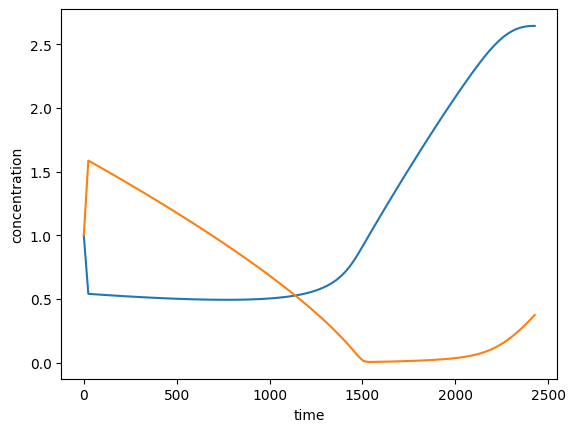

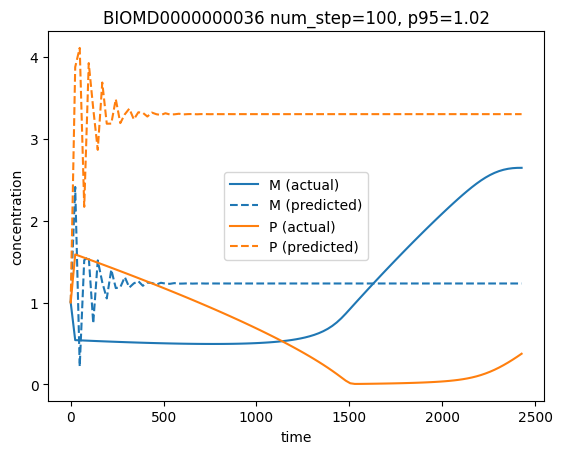

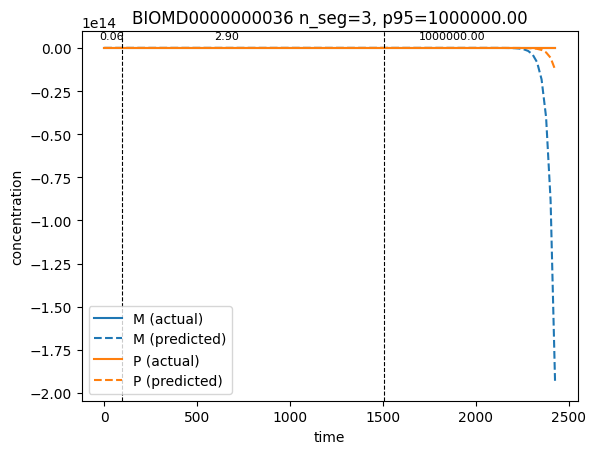

In [28]:
traj = Trajectory.makeBiomodel(36)
traj.plotTimecourse(legend=False)
lp = LinearPredictor(traj)
lp.plotPrediction()
tc = TrajectoryCollection.split(traj, timepoints=[100, 1500])
#tc.plotTimecourse(legend=False)
mlp = MultipleLinearPredictor(tc)
mlp.plotPrediction()

# Histograms

## Aggregate Data

In [ ]:
ffiles = [f for f in os.listdir(cn.DATA_DIR) if "linear_predictor_score" in f]
dfs = []
for ffile in ffiles:
    df = pd.read_csv(os.path.join(cn.DATA_DIR, ffile))
    dfs.append(df)
merged_df = pd.concat(dfs)
ALL_DF = merged_df.reset_index()
ALL_PATH = "all_data.csv"
ALL_DF.to_csv(ALL_PATH)

In [ ]:
MODEL_DF = ALL_DF[ALL_DF["aggregation_type"] == "model"]
p95_arr = np.sort(MODEL_DF["p95"].values)
count = len(p95_arr)
_, ax = plt.subplots()
ax.plot(p95_arr, np.array(range(count))/count)
ax.set_xlim(0, 1)
ax.set_title(f"RAE 95th Percentile for {len(MODEL_DF)} Models")

In [ ]:
SPECIES_DF = ALL_DF[ALL_DF["aggregation_type"] != "model"]
p95_arr = np.sort(SPECIES_DF["p95"].values)
count = len(p95_arr)
_, ax = plt.subplots()
ax.plot(p95_arr, np.array(range(count))/count)
ax.set_xlim(0, 1)
ax.set_title(f"RAE 95th Percentile for {len(SPECIES_DF)} Species")